In [21]:
# =====================================================
# Imports
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras

from lime import lime_image
from skimage.segmentation import mark_boundaries

from skimage.segmentation import slic

In [5]:
# Load Model
model = keras.models.load_model("../models/resnet50_pneumonia.keras")

In [6]:
# Choose an image
img_path = "../data/CHEST X RAY/test/PNEUMONIA/person1_virus_9.jpeg"

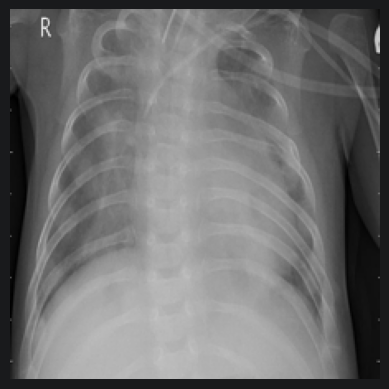

In [7]:
# Load Image
image = Image.open(img_path)

image = image.convert("RGB")

image = image.resize((224,224))

image = np.array(image)

plt.imshow(image)
plt.axis("off")
plt.show()

In [8]:
# Prediction function
def predict_fn(images):

    images = np.array(images)

    images = tf.keras.applications.resnet.preprocess_input(images)

    return model.predict(images, verbose=0)

In [9]:
# Create explainer
explainer = lime_image.LimeImageExplainer()

In [22]:
# Generate explanation
explanation = explainer.explain_instance(
    image=image,
    classifier_fn=predict_fn,
    top_labels=2,
    hide_color=0,
    num_samples=3000,
    segmentation_fn=lambda x: slic(
        x,
        n_segments=150,
        compactness=10,
        sigma=1
    )
)

100%|██████████| 3000/3000 [01:11<00:00, 41.84it/s]


In [27]:
# Get explanation image
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=15,
    hide_rest=False
)


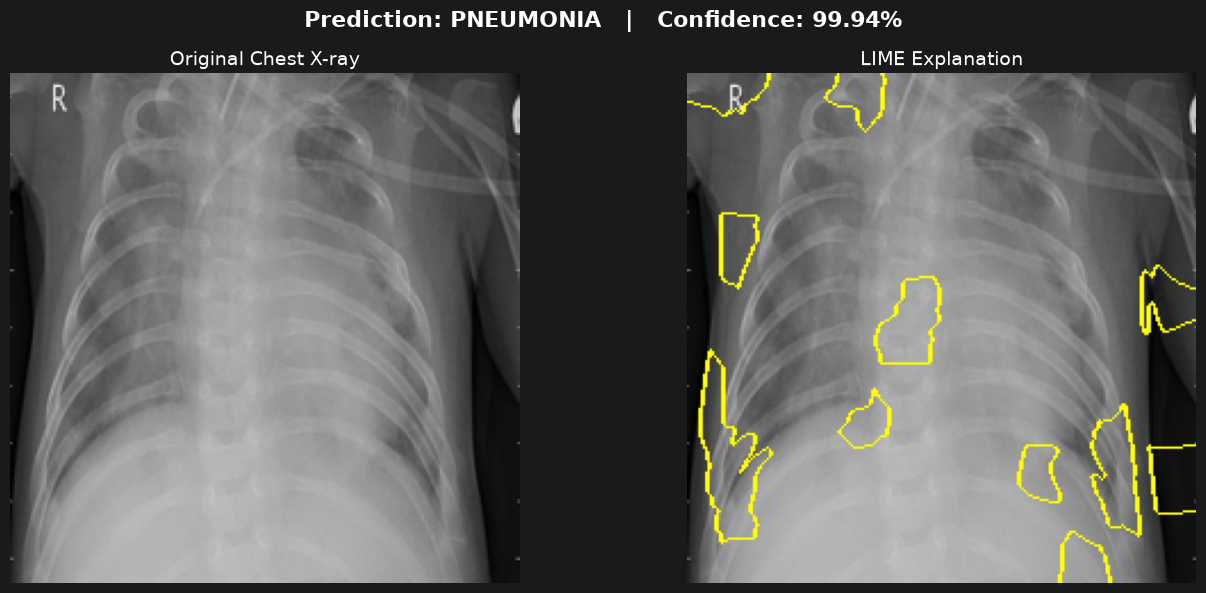

In [26]:
# Show result

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Original Image
ax[0].imshow(image)
ax[0].set_title("Original Chest X-ray", fontsize=14)
ax[0].axis("off")

# LIME Explanation
ax[1].imshow(mark_boundaries(image / 255.0, mask))
ax[1].set_title("LIME Explanation", fontsize=14)
ax[1].axis("off")

plt.suptitle(
    f"Prediction: {class_names[predicted_class]}   |   Confidence: {confidence*100:.2f}%",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [28]:
# Show prediction too
prediction = model.predict(
    np.expand_dims(
        tf.keras.applications.resnet.preprocess_input(image),
        axis=0
    ),
    verbose=0
)

class_names = ["NORMAL", "PNEUMONIA"]

predicted_class = np.argmax(prediction)

confidence = prediction[0][predicted_class]

print(f"Prediction : {class_names[predicted_class]}")
print(f"Confidence : {confidence*100:.2f}%")

Prediction : PNEUMONIA
Confidence : 99.94%
